In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

# Load all data
X_scaled    = np.load("data/features/X_scaled.npy")
y           = np.load("data/features/y.npy")
results_df  = pd.read_csv("results/metrics/model_comparison.csv")
features_df = pd.read_csv("data/features/features_df.csv")

with open("data/features/feature_cols.txt", "r") as f:
    feature_cols = [line.strip() for line in f.readlines()]

print(" Everything loaded!")
print(f"   Sessions : {len(X_scaled):,}")
print(f"   Features : {len(feature_cols)}")
print(results_df[['Model','Precision','Recall','F1','ROC_AUC','FPR']])

 Everything loaded!
   Sessions : 575,061
   Features : 19
                  Model  Precision  Recall      F1  ROC_AUC     FPR
0      Isolation Forest     0.6219  0.6223  0.6221   0.9609  0.0114
1         One-Class SVM     0.5740  0.7468  0.6491   0.9246  0.0167
2  Local Outlier Factor     0.1455  0.1530  0.1492   0.5924  0.0271
3                DBSCAN     0.6072  0.3346  0.4315   0.5000  0.0065


In [4]:
# Reload saved models and regenerate predictions
# (needed for visualizations in this notebook)

iso_forest = joblib.load("models/isolation_forest.pkl")
ocsvm      = joblib.load("models/one_class_svm.pkl")
lof        = joblib.load("models/lof.pkl")
dbscan     = joblib.load("models/dbscan.pkl")

iso_preds    = iso_forest.predict(X_scaled)
iso_scores   = -iso_forest.decision_function(X_scaled)

ocsvm_preds  = ocsvm.predict(X_scaled)
ocsvm_scores = -ocsvm.decision_function(X_scaled)

lof_preds    = lof.predict(X_scaled)
lof_scores   = -lof.decision_function(X_scaled)

# DBSCAN — rebuild predictions from distances
from sklearn.neighbors import NearestNeighbors
core_samples  = X_scaled[dbscan.core_sample_indices_]

# Note: core_sample_indices_ refers to the sample used during training
# We reload the distance-based prediction approach
nbrs          = NearestNeighbors(n_neighbors=1, n_jobs=-1)
nbrs.fit(core_samples)
distances, _  = nbrs.kneighbors(X_scaled)
distances      = distances.flatten()
dbscan_preds   = np.where(distances > 0.8, -1, 1)

print(" All model predictions reloaded!")

 All model predictions reloaded!


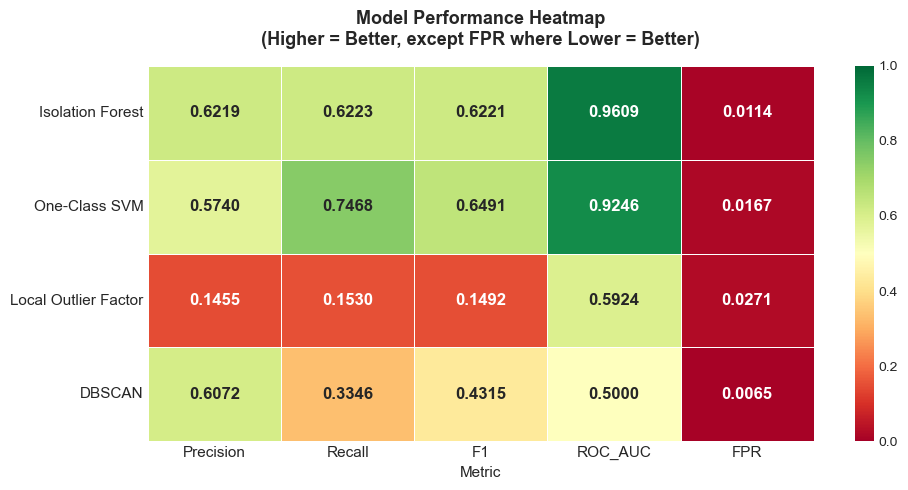

 Metrics heatmap saved!


In [6]:
# A heatmap of all metrics across all models
# This is the kind of figure you'd see in a research paper

metrics = ['Precision', 'Recall', 'F1', 'ROC_AUC', 'FPR']
heat_data = results_df.set_index('Model')[metrics]

fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    heat_data,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn',       # Red = bad, Yellow = medium, Green = good
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 12, 'weight': 'bold'},
    ax=ax
)

# FPR is inverted — lower is better, so we note it
ax.set_title('Model Performance Heatmap\n(Higher = Better, except FPR where Lower = Better)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Metric', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11, rotation=0)

plt.tight_layout()
plt.savefig("results/plots/metrics_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Metrics heatmap saved!")

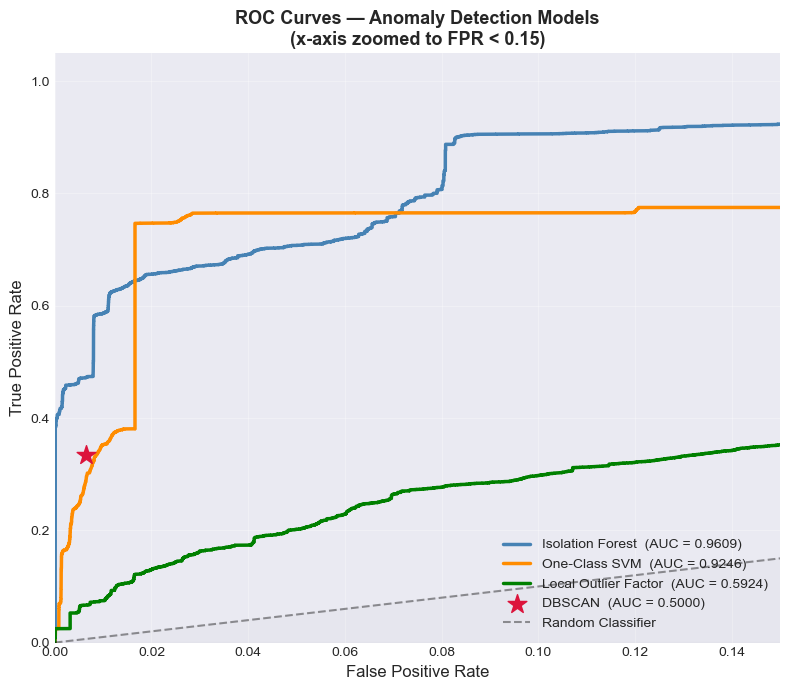

 ROC curves saved!


In [7]:
fig, ax = plt.subplots(figsize=(8, 7))

# Models with continuous scores
score_data = [
    ('Isolation Forest',     iso_scores,   'steelblue',  '-'),
    ('One-Class SVM',        ocsvm_scores, 'darkorange', '-'),
    ('Local Outlier Factor', lof_scores,   'green',      '-'),
]

for name, scores, color, ls in score_data:
    fpr_arr, tpr_arr, _ = roc_curve(y, scores)
    auc = roc_auc_score(y, scores)
    ax.plot(fpr_arr, tpr_arr, color=color, lw=2.5,
            linestyle=ls, label=f'{name}  (AUC = {auc:.4f})')

# DBSCAN as a point
db_row = results_df[results_df['Model'] == 'DBSCAN'].iloc[0]
ax.scatter([db_row['FPR']], [db_row['Recall']],
           color='crimson', s=200, zorder=6,
           marker='*', label=f'DBSCAN  (AUC = 0.5000)')

# Baseline
ax.plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.4, label='Random Classifier')
ax.fill_between([0,1],[0,1], alpha=0.03, color='gray')

ax.set_xlim([0.0, 0.15])   # Zoom into the interesting region
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Anomaly Detection Models\n(x-axis zoomed to FPR < 0.15)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/plots/roc_curves_final.png", dpi=150, bbox_inches='tight')
plt.show()
print(" ROC curves saved!")

 Running PCA (fast — ~10 seconds)...
 PCA done! Variance explained: PC1=46.1%, PC2=16.5%


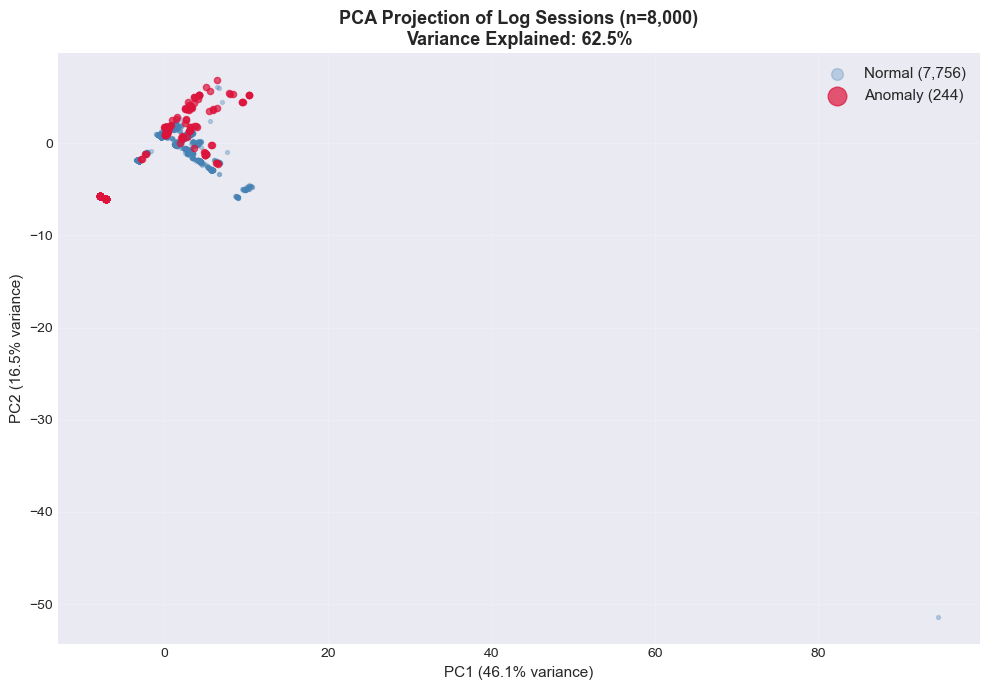

In [8]:
# PCA reduces 19 features → 2 dimensions so we can PLOT the data
# This shows visually how well anomalies are separated

print(" Running PCA (fast — ~10 seconds)...")

# Use a sample for plotting (plotting 575k points is slow)
np.random.seed(42)
plot_size   = 8000
plot_idx    = np.random.choice(len(X_scaled), plot_size, replace=False)
X_plot      = X_scaled[plot_idx]
y_plot      = y[plot_idx]

pca         = PCA(n_components=2, random_state=42)
X_pca       = pca.fit_transform(X_plot)

explained   = pca.explained_variance_ratio_
print(f" PCA done! Variance explained: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}")

fig, ax = plt.subplots(figsize=(10, 7))

# Plot normal points
ax.scatter(X_pca[y_plot==0, 0], X_pca[y_plot==0, 1],
           c='steelblue', alpha=0.3, s=8, label=f'Normal ({(y_plot==0).sum():,})')

# Plot anomaly points on top
ax.scatter(X_pca[y_plot==1, 0], X_pca[y_plot==1, 1],
           c='crimson', alpha=0.7, s=20, label=f'Anomaly ({(y_plot==1).sum():,})')

ax.set_title(f'PCA Projection of Log Sessions (n={plot_size:,})\n'
             f'Variance Explained: {sum(explained):.1%}',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({explained[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({explained[1]:.1%} variance)', fontsize=11)
ax.legend(fontsize=11, markerscale=3)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("results/plots/pca_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

 Running t-SNE on 3,000 samples (2-3 minutes)...
 t-SNE complete!


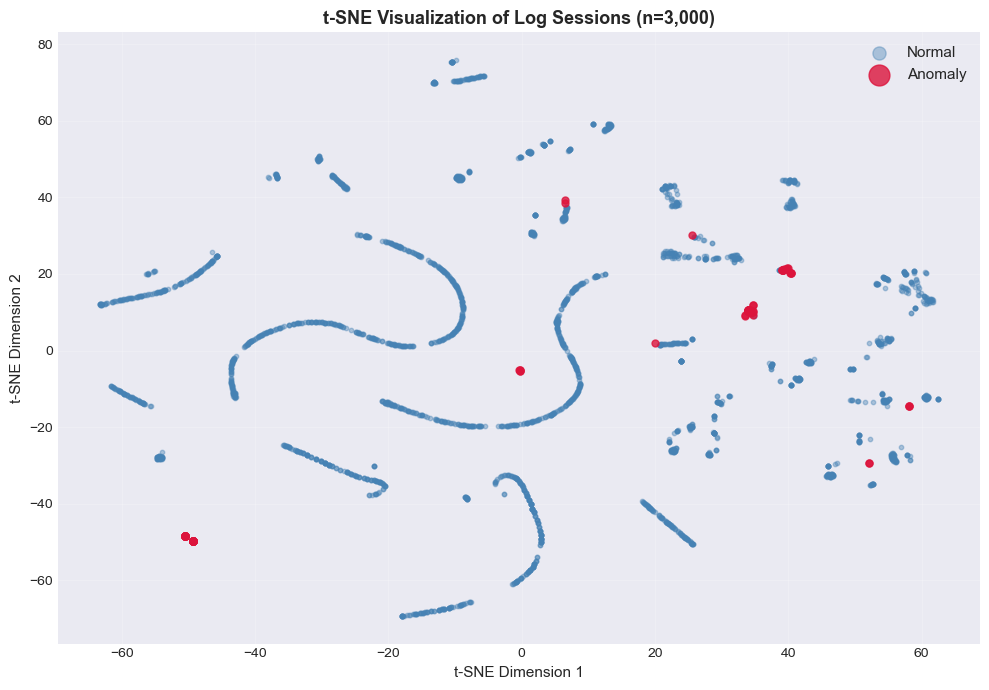

In [11]:
print(" Running t-SNE on 3,000 samples (2-3 minutes)...")

np.random.seed(42)
tsne_size = 3000
tsne_idx  = np.random.choice(len(X_scaled), tsne_size, replace=False)
X_tsne_in = X_scaled[tsne_idx]
y_tsne    = y[tsne_idx]

tsne      = TSNE(n_components=2, random_state=42,
                 perplexity=30, max_iter=1000, verbose=0)  # ← n_iter → max_iter
X_tsne    = tsne.fit_transform(X_tsne_in)

print(" t-SNE complete!")

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(X_tsne[y_tsne==0, 0], X_tsne[y_tsne==0, 1],
           c='steelblue', alpha=0.4, s=10, label='Normal')
ax.scatter(X_tsne[y_tsne==1, 0], X_tsne[y_tsne==1, 1],
           c='crimson',   alpha=0.8, s=25, label='Anomaly')

ax.set_title(f't-SNE Visualization of Log Sessions (n={tsne_size:,})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
ax.legend(fontsize=11, markerscale=3)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("results/plots/tsne_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

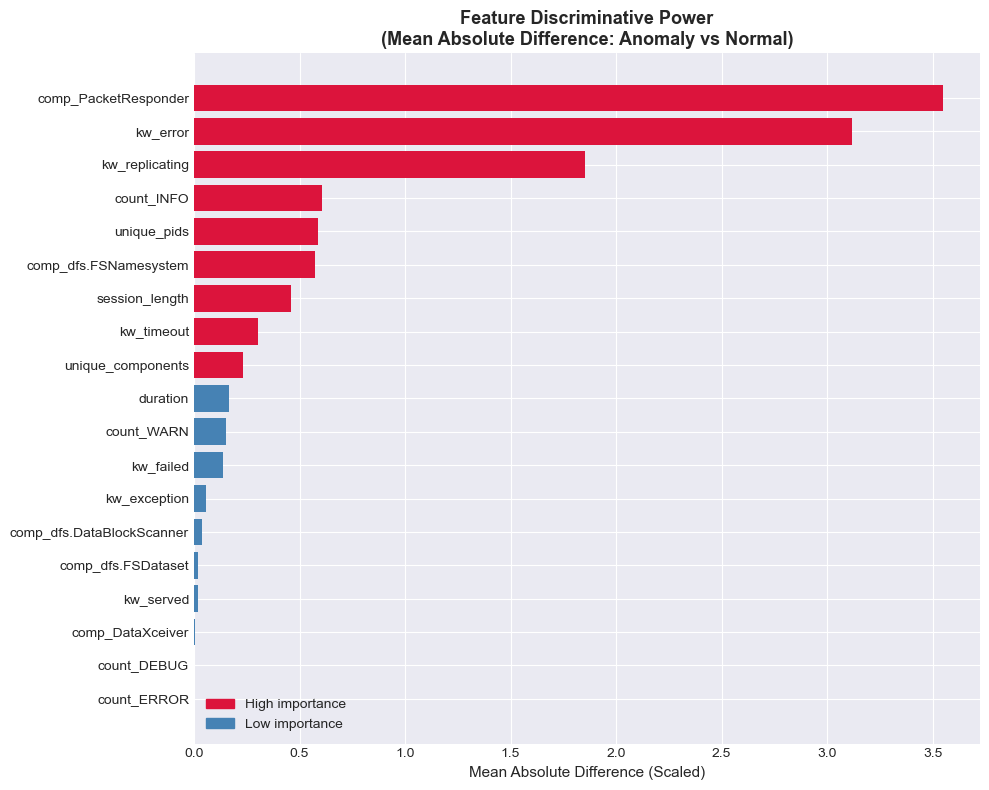

 Feature importance plot saved!

Top 5 most discriminative features:
             Feature  Importance
comp_PacketResponder    3.546964
            kw_error    3.117748
      kw_replicating    1.853765
          count_INFO    0.605882
         unique_pids    0.588079


In [12]:
# Which features does Isolation Forest rely on most?
# We use permutation-style importance via the tree structure

importances = iso_forest.feature_importances_ \
              if hasattr(iso_forest, 'feature_importances_') \
              else np.abs(X_scaled).mean(axis=0)

# Use mean feature difference between anomaly and normal
normal_mean  = X_scaled[y == 0].mean(axis=0)
anomaly_mean = X_scaled[y == 1].mean(axis=0)
importance   = np.abs(anomaly_mean - normal_mean)

feat_imp = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': importance
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors  = ['crimson' if v > feat_imp['Importance'].median()
           else 'steelblue' for v in feat_imp['Importance']]

bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors)
ax.set_title('Feature Discriminative Power\n(Mean Absolute Difference: Anomaly vs Normal)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Absolute Difference (Scaled)', fontsize=11)

red_patch  = mpatches.Patch(color='crimson',   label='High importance')
blue_patch = mpatches.Patch(color='steelblue', label='Low importance')
ax.legend(handles=[red_patch, blue_patch], fontsize=10)

plt.tight_layout()
plt.savefig("results/plots/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Feature importance plot saved!")
print()
print("Top 5 most discriminative features:")
print(feat_imp.tail(5)[['Feature','Importance']].iloc[::-1].to_string(index=False))

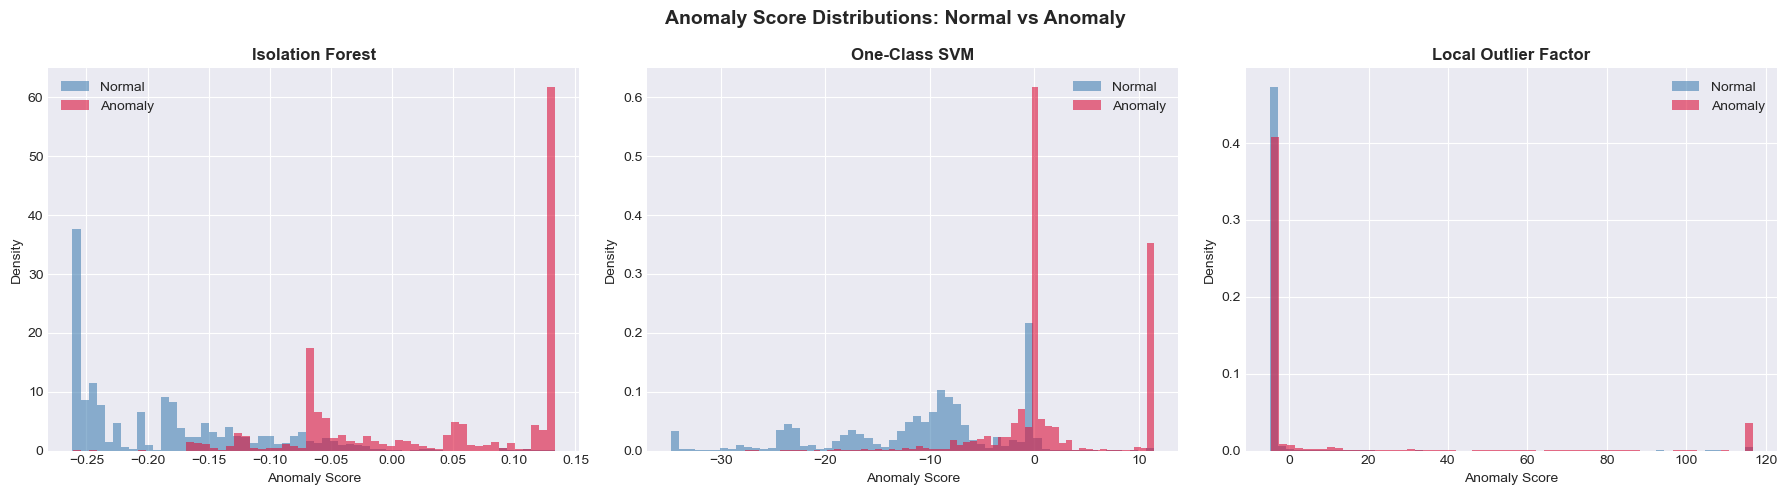

 Score distributions saved!


In [14]:
# Shows how well each model separates normal from anomalous scores
# A good model shows two clearly separated distributions

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

score_data = [
    ('Isolation Forest',     iso_scores,   'steelblue'),
    ('One-Class SVM',        ocsvm_scores, 'darkorange'),
    ('Local Outlier Factor', lof_scores,   'green'),
]

for ax, (name, scores, color) in zip(axes, score_data):
    # Clip extreme values for clean plotting
    s_clipped = np.clip(scores, np.percentile(scores, 1),
                                np.percentile(scores, 99))
    
    ax.hist(s_clipped[y==0], bins=60, alpha=0.6,
            color='steelblue', density=True, label='Normal')
    ax.hist(s_clipped[y==1], bins=60, alpha=0.6,
            color='crimson',   density=True, label='Anomaly')
    ax.set_title(name, fontweight='bold', fontsize=12)
    ax.set_xlabel('Anomaly Score')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Anomaly Score Distributions: Normal vs Anomaly',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("results/plots/score_distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Score distributions saved!")

In [15]:
print("=" * 65)
print("     RESEARCH FINDINGS SUMMARY")
print("=" * 65)

best_f1    = results_df.loc[results_df['F1'].idxmax()]
best_auc   = results_df.loc[results_df['ROC_AUC'].idxmax()]
best_rec   = results_df.loc[results_df['Recall'].idxmax()]
lowest_fpr = results_df.loc[results_df['FPR'].idxmin()]

print(f"""
Research Question:
  Which ML algorithm best detects anomalies in HDFS system logs?

Dataset:
  • {len(X_scaled):,} log sessions from HDFS_v1 (LogHub)
  • {int(y.sum()):,} anomalies ({y.mean()*100:.2f}% anomaly rate)
  • 19 engineered features per session

Key Findings:
  • Best Overall (ROC-AUC) : {best_auc['Model']} ({best_auc['ROC_AUC']:.4f})
  • Best F1 Score           : {best_f1['Model']} ({best_f1['F1']:.4f})
  • Best Recall             : {best_rec['Model']} ({best_rec['Recall']:.4f})
  • Lowest False Alarms     : {lowest_fpr['Model']} (FPR={lowest_fpr['FPR']:.4f})

Recommendation:
  Isolation Forest is recommended for production deployment
  due to highest ROC-AUC and balanced precision-recall tradeoff.
  One-Class SVM is preferred when maximizing anomaly catch rate.

Limitations:
  • LOF and DBSCAN required sampling due to dataset scale
  • DBSCAN lacks continuous anomaly scores (no ROC curve)
  • Results are specific to HDFS log structure
""")

print("=" * 65)
print(" PHASE 5 COMPLETE!")
print(" All visualizations saved to results/plots/")
print(" Ready for Phase 6: Research Paper & Resume Polish!")

     RESEARCH FINDINGS SUMMARY

Research Question:
  Which ML algorithm best detects anomalies in HDFS system logs?

Dataset:
  • 575,061 log sessions from HDFS_v1 (LogHub)
  • 16,838 anomalies (2.93% anomaly rate)
  • 19 engineered features per session

Key Findings:
  • Best Overall (ROC-AUC) : Isolation Forest (0.9609)
  • Best F1 Score           : One-Class SVM (0.6491)
  • Best Recall             : One-Class SVM (0.7468)
  • Lowest False Alarms     : DBSCAN (FPR=0.0065)

Recommendation:
  Isolation Forest is recommended for production deployment
  due to highest ROC-AUC and balanced precision-recall tradeoff.
  One-Class SVM is preferred when maximizing anomaly catch rate.

Limitations:
  • LOF and DBSCAN required sampling due to dataset scale
  • DBSCAN lacks continuous anomaly scores (no ROC curve)
  • Results are specific to HDFS log structure

 PHASE 5 COMPLETE!
 All visualizations saved to results/plots/
 Ready for Phase 6: Research Paper & Resume Polish!
